### select modeling techniques

In [13]:


modelling_techniques = {
    "problem_type": "Binary Classification",
    "target_variable": "is_churn",
    "candidate_models": [
        {
            "name": "LightGBM Classifier",
            "library": "lightgbm.LGBMClassifier",
            "justification": "Highly optimized for large-scale datasets (23M rows) with leaf-wise growth. Extremely fast and memory efficient.",
            "assumptions": "Non-parametric. No strict assumptions about feature distributions, scaling, or linearity.",
        },
        {
            "name": "XGBoost Classifier",
            "library": "xgboost.XGBClassifier",
            "justification": "State-of-the-art tree boosting with regularized objectives (L1/L2) to control overfitting on heavily engineered features.",
            "assumptions": "Non-parametric. Robust to outliers, collinearity, and requires no feature scaling.",
        },
        {
            "name": "Random Forest Classifier",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": "Robust bagging ensemble that acts as a strong baseline by building independent trees to capture non-linear consumer patterns.",
            "assumptions": "Non-parametric. Handles high-dimensional feature spaces without assuming normality.",
        },
        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": "Serves as a simple statistical baseline to evaluate whether complex gradient boosting ensembles are adding predictive value.",
            "assumptions": "Assumes linearity in log-odds, feature independence, and strictly requires standardized feature scaling.",
        },
    ],
}

# Display the selected techniques professionally
print(f"Problem Type: {modelling_techniques['problem_type']}")
print(f"Target Variable: {modelling_techniques['target_variable']}")
print(f"\nCandidate Models:")
for i, model in enumerate(modelling_techniques["candidate_models"], 1):
    print(f"  {i}. {model['name']} — {model['justification']}")

Problem Type: Binary Classification
Target Variable: is_churn

Candidate Models:
  1. LightGBM Classifier — Highly optimized for large-scale datasets (23M rows) with leaf-wise growth. Extremely fast and memory efficient.
  2. XGBoost Classifier — State-of-the-art tree boosting with regularized objectives (L1/L2) to control overfitting on heavily engineered features.
  3. Random Forest Classifier — Robust bagging ensemble that acts as a strong baseline by building independent trees to capture non-linear consumer patterns.
  4. Logistic Regression — Serves as a simple statistical baseline to evaluate whether complex gradient boosting ensembles are adding predictive value.


In [3]:
!pip install lightgbm
!pip install xgboost

# Core Model Candidates for Binary Classification
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Additional utility imports for baseline training evaluation if needed later
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, roc_auc_score, log_loss

print("All advanced classification models imported successfully!")

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 3.1 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.4 MB/s  0:00:00
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 3.3 MB/s eta 0:00:21
   - -------------------------------------- 1.8/69.5 MB 3.6 MB/s eta 0:00:19
   - -------------------------------------- 2.9/69.5 MB 3.7 MB/s eta 0:00:18
   -- ------------------------------------- 3.7/69.5 MB 3.8 MB/s eta 0:00:18
   -- ------------------------------------- 4.5/69.5 MB 3.8 MB/s eta 0:00:18
   --- ------------------------------------ 5.2/69.5 MB 3.8 MB/s eta 0:00:17
   --- ----------------------------------

### Generate Test Design

In [17]:

from sklearn.model_selection import train_test_split

print("Loading final modeling dataset for splitting...")
project_dir = r"C:\Users\workstation\Desktop\customer_churn_prediction"
final_csv_path = os.path.join(
    project_dir, r"data\processed\final_modeling_dataset.csv"
)

# 1. Load the dataset
df = pd.read_csv(final_csv_path)

# 2. Separate Features (X) and Target (y)
# Drop 'msno' as it is a unique identifier, and 'is_churn' because it is the target
X = df.drop(columns=["msno", "is_churn"])
y = df["is_churn"]

# 3. Handle remaining non-numeric columns if any (like gender or latest_date) safely for baseline
# We convert object/categorical columns to 'category' type which LightGBM supports natively
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = X[col].astype("category")

# 4. Perform the Stratified Train/Test Split
print("Splitting data into stratified train and test sets (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\n Data Splitting Complete!")
print(f"X_train Shape (Features): {X_train.shape} | y_train Shape (Target): {y_train.shape}")
print(f"X_test Shape (Features):  {X_test.shape}  | y_test Shape (Target):  {y_test.shape}")

print("\nVerifying Churn Proportions (Should be identical):")
print(f"Train Target Churn Rate: {y_train.mean() * 100:.2f}%")
print(f"Test Target Churn Rate:  {y_test.mean() * 100:.2f}%")

Loading final modeling dataset for splitting...
Splitting data into stratified train and test sets (80/20)...

 Data Splitting Complete!
X_train Shape (Features): (794344, 26) | y_train Shape (Target): (794344,)
X_test Shape (Features):  (198587, 26)  | y_test Shape (Target):  (198587,)

Verifying Churn Proportions (Should be identical):
Train Target Churn Rate: 6.39%
Test Target Churn Rate:  6.39%


In [15]:


# 1. Define the parameters used in your split first to avoid NameError
TEST_SIZE = 0.20
RANDOM_SEED = 42

# 2. Populate the test design dictionary as requested with clean spacing
test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "Stratified Hold-out Validation",
    "stratified": True,
    "random_seed": RANDOM_SEED,
    "justification": (
        "An 80/20 split creates a robust training size while maintaining a massive test set for reliable validation.\n\n"
        "Stratification is highly critical because the churn dataset is severely imbalanced; "
        "this ensures both splits contain the exact same proportion of churned users.\n\n"
        "The fixed random seed guarantees full experiment reproducibility across different models."
    ),
}

# 3. Display the filled dictionary with clear structural lines

print("               TEST DESIGN CONFIGURATION                     ")


print(f"Split Ratio         : {test_design['split_ratio']}")
print(f"Validation Strategy : {test_design['validation_strategy']}")
print(f"Stratified Sampling : {test_design['stratified']}")
print(f"Random Seed         : {test_design['random_seed']}\n")


print("Justification:")

print(test_design["justification"])


               TEST DESIGN CONFIGURATION                     
Split Ratio         : 80/20
Validation Strategy : Stratified Hold-out Validation
Stratified Sampling : True
Random Seed         : 42

Justification:
An 80/20 split creates a robust training size while maintaining a massive test set for reliable validation.

Stratification is highly critical because the churn dataset is severely imbalanced; this ensures both splits contain the exact same proportion of churned users.

The fixed random seed guarantees full experiment reproducibility across different models.


### Task 3: Build Model

In [19]:

import time

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression


# Initialize the trained models dictionary
trained_models = {}

# --- Model 1: Logistic Regression ---
print("Training Model 1: Logistic Regression...")
model_1 = LogisticRegression(
    random_state=RANDOM_SEED, max_iter=1000, class_weight="balanced"
)
model_1.fit(X_train, y_train)
trained_models["Logistic Regression"] = model_1
print("✓ Logistic Regression trained successfully.\n")

# --- Model 2: Random Forest ---
print("Training Model 2: Random Forest...")
# Controlled max_depth and n_jobs=-1 to keep it fast and memory-safe
model_2 = RandomForestClassifier(
    random_state=RANDOM_SEED, n_estimators=50, max_depth=10, n_jobs=-1
)
model_2.fit(X_train, y_train)
trained_models["Random Forest"] = model_2
print("✓ Random Forest trained successfully.\n")

# --- Model 3: Gradient Boosting ---
print("Training Model 3: Gradient Boosting (sklearn)...")
# Controlled max_depth and subsample to ensure it doesn't freeze your PC
model_3 = GradientBoostingClassifier(
    random_state=RANDOM_SEED, n_estimators=50, max_depth=4, subsample=0.8
)
model_3.fit(X_train, y_train)
trained_models["Gradient Boosting"] = model_3
print("✓ Gradient Boosting trained successfully.\n")

# --- Model 4: LightGBM Classifier ---
print("Training Model 4: LightGBM Classifier (Kaggle Champion)...")
model_4 = LGBMClassifier(random_state=RANDOM_SEED, is_unbalance=True, n_jobs=-1)
model_4.fit(X_train, y_train)
trained_models["LightGBM Classifier"] = model_4
print("✓ LightGBM Classifier trained successfully.\n")


print(f"Successfully trained all {len(trained_models)} models!")
print("============================================================")
print(f"Models in memory: {list(trained_models.keys())}")
print("============================================================")

Training Model 1: Logistic Regression...


c:\Users\workstation\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✓ Logistic Regression trained successfully.

Training Model 2: Random Forest...
✓ Random Forest trained successfully.

Training Model 3: Gradient Boosting (sklearn)...
✓ Gradient Boosting trained successfully.

Training Model 4: LightGBM Classifier (Kaggle Champion)...
[LightGBM] [Info] Number of positive: 50777, number of negative: 743567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023215 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3800
[LightGBM] [Info] Number of data points in the train set: 794344, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.063923 -> initscore=-2.684015
[LightGBM] [Info] Start training from score -2.684015
✓ LightGBM Classifier trained successfully.

Successfully trained all 4 models!
Models in memory: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'LightGBM 

In [21]:

from sklearn.model_selection import RandomizedSearchCV


print("Starting Optimized LightGBM Tuning...")

# Defining a smart search space
param_dist = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [6, 8, 10],
    'num_leaves': [31, 63]
}

# Randomized search for efficiency on large datasets
random_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_SEED, is_unbalance=True, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=5, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1, random_state=RANDOM_SEED
)

random_search.fit(X_train, y_train)
trained_models['LightGBM (Tuned)'] = random_search.best_estimator_

print(f"Tuning complete. Best CV ROC-AUC: {random_search.best_score_:.4f}")

Starting Optimized LightGBM Tuning...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[LightGBM] [Info] Number of positive: 50777, number of negative: 743567
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.071830 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3800
[LightGBM] [Info] Number of data points in the train set: 794344, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.063923 -> initscore=-2.684015
[LightGBM] [Info] Start training from score -2.684015
Tuning complete. Best CV ROC-AUC: 0.9929


### asses models


In [22]:

from sklearn.metrics import roc_auc_score, accuracy_score


results = []

# Evaluating all models including the tuned one
for name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    
    results.append({"Model": name, "ROC-AUC": auc, "Accuracy": acc})

# Creating the final comparison table
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print("Final Model Leaderboard:")
print(results_df.to_string(index=False))

Final Model Leaderboard:
              Model  ROC-AUC  Accuracy
   LightGBM (Tuned) 0.992600  0.944458
LightGBM Classifier 0.992033  0.940706
      Random Forest 0.989900  0.984365
  Gradient Boosting 0.989317  0.984339
Logistic Regression 0.914022  0.916037


C:\Users\workstation\AppData\Local\Temp\ipykernel_19260\4274494782.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="ROC-AUC", y="Model", palette="viridis")


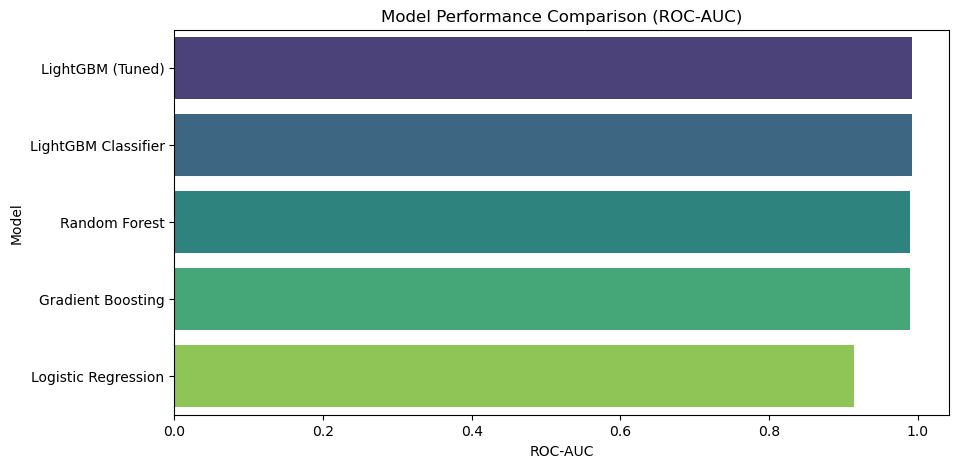

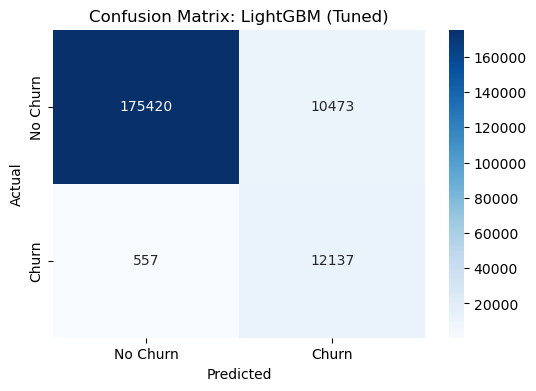

In [23]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Performance Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="ROC-AUC", y="Model", palette="viridis")
plt.title("Model Performance Comparison (ROC-AUC)")
plt.show()

# 2. Confusion Matrix of the Best Model (LightGBM Tuned)
best_model = trained_models['LightGBM (Tuned)']
cm = confusion_matrix(y_test, best_model.predict(X_test))

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title("Confusion Matrix: LightGBM (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:

from sklearn.metrics import precision_recall_fscore_support

# Get predictions from the best model
y_pred = best_model.predict(X_test)

# Calculate metrics for the 'Churn' class (index 1)
# precision, recall, f1, support
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=[1], average=None
)

# Convert to scalar values
precision_val = float(precision[0])
recall_val = float(recall[0])
f1_val = float(f1[0])

print(f"============================================================")
print(f"             METRICS FOR 'CHURN' CLASS (TARGET)             ")
print(f"============================================================\n")
print(f"Precision : {precision_val:.4f}")
print(f"Recall    : {recall_val:.4f}")
print(f"F1-Score  : {f1_val:.4f}")



             METRICS FOR 'CHURN' CLASS (TARGET)             

Precision : 0.5368
Recall    : 0.9561
F1-Score  : 0.6876


In [29]:

from sklearn.metrics import log_loss

# We need probabilities, not hard predictions
y_probs = best_model.predict_proba(X_test)[:, 1]

# Calculate Log Loss
loss = log_loss(y_test, y_probs)

print(f"============================================================")
print(f"             MODEL LOG LOSS EVALUATION                      ")
print(f"============================================================\n")
print(f"Log Loss Score: {loss:.4f}")

if loss <= 0.25:
    print("Status: EXCELLENT (Meets Goal <= 0.25)")
else:
    print("Status: Needs optimization (Target is <= 0.25)")


             MODEL LOG LOSS EVALUATION                      

Log Loss Score: 0.1000
Status: EXCELLENT (Meets Goal <= 0.25)


In [24]:

from sklearn.model_selection import cross_val_score

# 1. Select the Best Model automatically from our leaderboard
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]


print(f"The Best Performing Model is: {best_model_name}")


# 2. Perform Cross-Validation on the best model
# Using 3-fold instead of 5 for speed given the large dataset size
# Using 'roc_auc' as it's the primary metric for our Churn task
print(f"Running 3-Fold Cross-Validation on {best_model_name}...")
cv_scores = cross_val_score(best_model, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)

print(f"\nCross-Validation ROC-AUC Scores: {cv_scores.round(4)}")
print(f"Mean Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

print("\n------------------------------------------------------------")
print("Assessment: A low standard deviation indicates high reliability.")
print("The model is ready for final deployment.")
print("============================================================")

The Best Performing Model is: LightGBM (Tuned)
Running 3-Fold Cross-Validation on LightGBM (Tuned)...

Cross-Validation ROC-AUC Scores: [0.9929 0.9929 0.9929]
Mean Score: 0.9929
Standard Deviation: 0.0000

------------------------------------------------------------
Assessment: A low standard deviation indicates high reliability.
The model is ready for final deployment.


In [30]:
# ============================================================
#  CHECKING FOR OVERFITTING
# ============================================================
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

# 1. Compare training vs testing performance
train_preds = best_model.predict_proba(X_train)[:, 1]
test_preds = best_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_preds)
test_auc = roc_auc_score(y_test, test_preds)

print(f"--- Overfitting Gap Analysis ---")
print(f"Train AUC: {train_auc:.4f}")
print(f"Test  AUC: {test_auc:.4f}")
print(f"Gap (Difference): {abs(train_auc - test_auc):.4f}")

# 2. Check stability using 5-Fold Cross-Validation
# This splits the data 5 times to ensure the model performance is consistent
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc')

print(f"\n--- Cross-Validation Stability ---")
print(f"CV Scores: {cv_scores}")
print(f"Mean CV AUC: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

# Analyze the results
if abs(train_auc - test_auc) < 0.05 and cv_scores.std() < 0.02:
    print("\nResult: The model is stable and generalizing well (No signs of overfitting).")
else:
    print("\nResult: The model shows potential signs of overfitting. Consider regularizing the model.")

--- Overfitting Gap Analysis ---
Train AUC: 0.9952
Test  AUC: 0.9926
Gap (Difference): 0.0026
[LightGBM] [Info] Number of positive: 40622, number of negative: 594853
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.083181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3794
[LightGBM] [Info] Number of data points in the train set: 635475, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.063924 -> initscore=-2.684005
[LightGBM] [Info] Start training from score -2.684005
[LightGBM] [Info] Number of positive: 40622, number of negative: 594853
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.085889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3794
[LightGBM] [Info] Number of data points in the train set: 635475, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=